Much has changed in the ten years since I published [_Density Estimation with Dirichlet Process Mixtures using PyMC3_](https://austinrochford.com/posts/2016-02-25-density-estimation-dpm.html). To name a few new developments:

* [PyMC](https://www.pymc.io/welcome.html) is now on version 6, it was on version 3.
* [ArviZ](https://www.arviz.org/en/latest/) and [PreliZ](https://preliz.readthedocs.io/en/latest/index.html) did not exist.
* [Nutpie](https://pymc-devs.github.io/nutpie/) did not exist.
* I understood the math, probability, and statistics in question less well than I do now.

This post revisits the first example in the former post, waiting times between eruptions of the [Old Faithful](https://en.wikipedia.org/wiki/Old_Faithful) in Yellowstone National Park, from a slightly different perspective.

In this post, we will use the Old Faithful [data](https://vincentarelbundock.github.io/Rdatasets/doc/MASS/geyser.html) to explore ([normal](https://en.wikipedia.org/wiki/Normal_distribution)) [mixture models](https://en.wikipedia.org/wiki/Mixture_model) and computational considerations in their Bayesian estimation.  We will begin with a simple finite mixture model, explore its identifiability, then progress to [nonparametric](https://en.wikipedia.org/wiki/Nonparametric_statistics) [Dirichlet process mixture models](https://en.wikipedia.org/wiki/Dirichlet_process#Use_in_Dirichlet_mixture_models) as in the prior post.

First we make the necessary Python imports and do some light configuration.

In [1]:
%matplotlib inline

In [2]:
from math import ceil

import arviz as az
import numpy as np
import nutpie
import polars as pl
import preliz as pz
import pymc as pm
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import ticker
from scipy import stats
from seaborn import objects as so

In [3]:
sns.set(color_codes=True)

Next we load the data from [GitHub](https://vincentarelbundock.github.io/Rdatasets/).

In [4]:
DATA_URL = "https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv"

In [5]:
def standardize(name):
    col = pl.col(name)

    return (col - col.mean()) / col.std()


std_wait = (
    pl.read_csv(DATA_URL)
    .select(standardize("waiting"))
    .rename({"waiting": "std_wait"})
    .to_numpy()
    .squeeze()
)

## Exploratory data analysis

First we visualize the distribution of the (standardized) wait times between eruptions as a histogram.

In [6]:
OF_XLABEL = "Waiting time\n(standardized)"

In [7]:
hist = (
    so.Plot(std_wait)
    .add(so.Bar(), so.Hist(bins=20, stat="density"))
    .scale(y=so.Continuous().tick(at=[]))
    .label(x=OF_XLABEL, y="Probability density", title="Old Faithful")
)

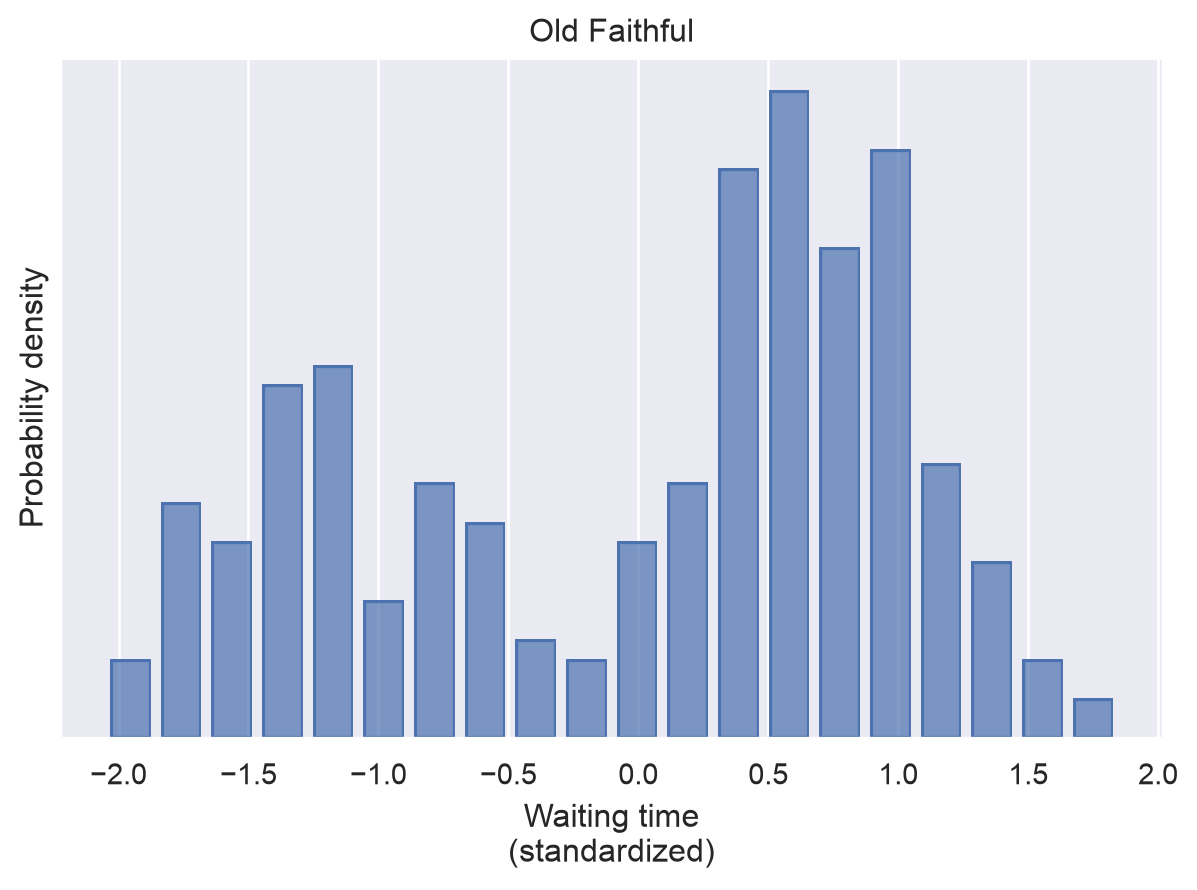

In [8]:
hist

Visually, it seems plausible that this data is from a combination (mixture) of two normal distributions, one centered just below $-1$ and one between $0.5$ and $1$.

Adding a Gaussian [kernel density estimator](https://en.wikipedia.org/wiki/Kernel_density_estimation) to the histogram seems to confirm this.  Our goal in this post is to show several methods to model this density using Bayesian statistics, and discuss some of the computational properties of those models.

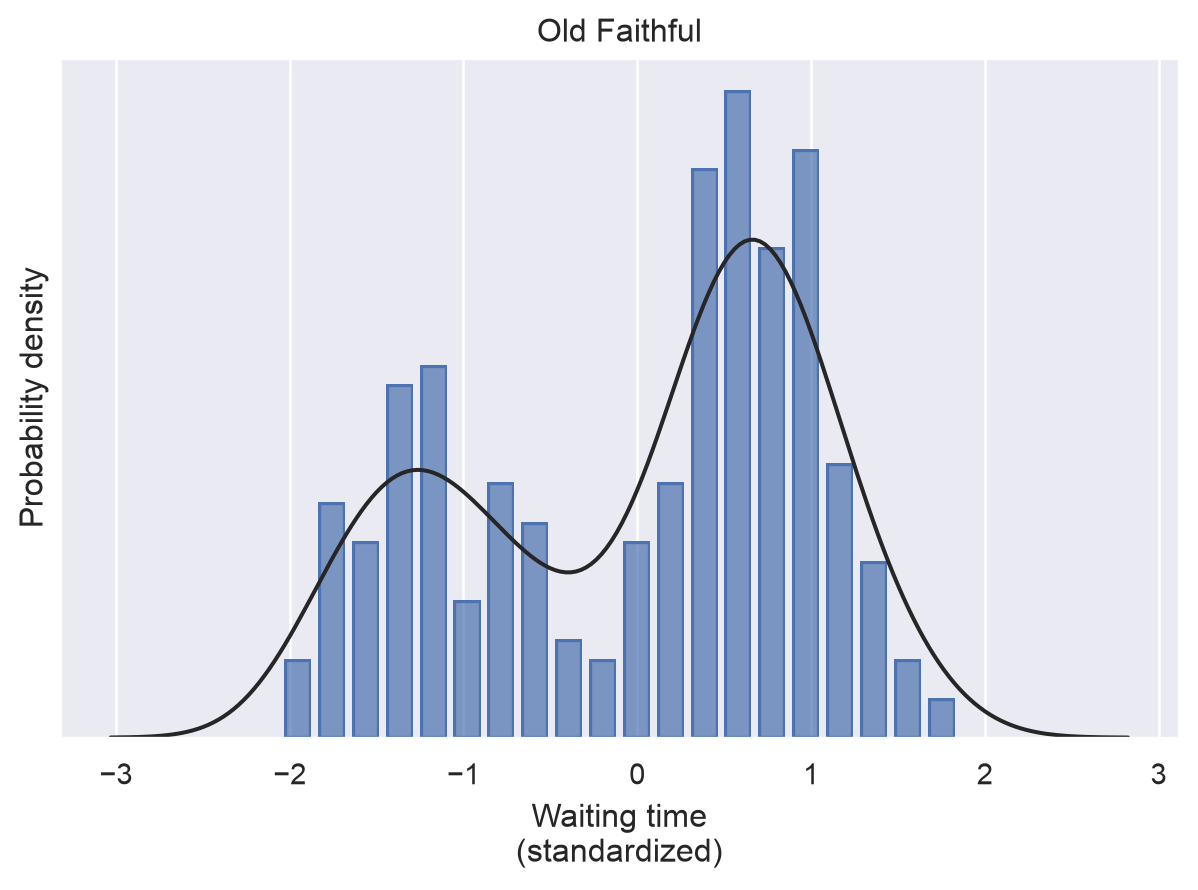

In [9]:
hist.add(so.Line(color="k"), so.KDE())

## Mixture models

### A crash course

Mixture models are useful when we suspect, as with the Old Faithful data, that the data generating process is a combination of simpler component distributions.  Formally, assume there are $K$ component distributions, each with probability density function $f_k(\cdot\ |\ \Theta_k)$ for $k = 1, 2, \ldots, K$.  We assume the probability that an observation is generated from the $k$-th component of the mixture is $w_k$ for $k = 1, 2, \ldots, K$.

The simplest way to sample from such a mixture model is

1. sample $\hat{k} \sim \text{Cat}(w_1, w_2, \ldots, w_K)$, then
2. sample $x \sim f_{\hat{k}}(\cdot\ |\ \Theta_{\hat{k}}).$

Below we illustrate this sampling scheme for a three-component normal mixture.

In [10]:
SEED = 123456789

rng = np.random.default_rng(SEED)

In [11]:
N_SIM = 2_000

W = np.array([0.2, 0.5, 0.3])

MU = np.array([0, 0.75, 2])
SIGMA = 0.25

In [12]:
k_hat = rng.choice(3, p=W, size=N_SIM)
x = rng.normal(MU[k_hat], SIGMA)

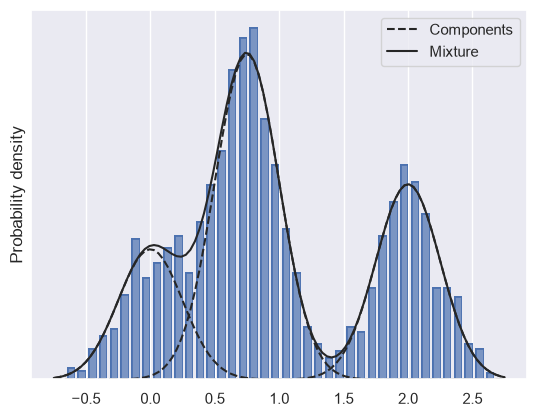

In [13]:
_, ax = plt.subplots()

sim_grid = np.linspace(-0.75, 2.75, 100)
comp_pdf = stats.norm.pdf(sim_grid[:, np.newaxis], MU[np.newaxis], SIGMA)

ax.plot(
    sim_grid, W * comp_pdf, c="k", ls="--", label=["Components"] + ["_"] * (W.size - 1)
)
ax.plot(sim_grid, comp_pdf @ W, c="k", label="Mixture")

ax.legend()

(
    so.Plot(x)
    .add(so.Bar(), so.Hist(bins=40, stat="density"))
    .scale(y=so.Continuous().tick(at=[]))
    .label(y="Probability density")
    .on(ax)
    .show()
)

In addition to a histogram of the samples, this plot shows the component and combined mixture probability density functions.

### Bayesian mixture models

In the rest of this post, we will explore Bayesian inference for mixture models.  To make these models Bayesian, we need to specify priors on the mixture weights $w_k$ and the component distribution parameters $\Theta_k$.

We start with the simplest case where the target number of normal components, $K$, is known.  In this case of Old Faithful, we strongly suspect $K = 2$.

In [14]:
K = 2

GRID = np.linspace(-2.5, 2.5, 200)

COORDS = {"component": np.arange(K), "grid": GRID}

We now turn to implementing a Bayesian normal mixture model in PyMC.  While we could translate the sampling scheme above fairly straightforwardly, we would not be able to take advantage of Nutpie's strong sampling performance, which does not work for discrete latent variables.  Instead, we use one of the applied Bayesian statistician's go-to tricks, [marginalization of discrete latent parameters](https://mc-stan.org/docs/2_20/stan-users-guide/rao-blackwell-section.html).  Marginalization removes the need to sample the discrete values $\hat{k}$ explicitly, instead combining the prior and component likelihoods and only then sampling.

First, we use a [Dirichlet](https://en.wikipedia.org/wiki/Dirichlet_distribution) prior on the mixture weights,

$$w_k \sim \text{Dir}(1, 1).$$

Note that for these hyperparameters, this distribution is uniform on the simplex.

In [15]:
with pm.Model(coords=COORDS) as finite_model:
    w = pm.Dirichlet("w", np.ones(K))

Next we place priors on the component parameters

$$
\begin{align}
\mu_1, \mu_2 & \sim N(0, 2.5^2) \\
\sigma_1, \sigma_2 & \sim \text{Half-}N(2.5^2).
\end{align}
$$

In [16]:
with finite_model:
    μ = pm.Normal("μ", 0, 2.5, dims="component")
    σ = pm.HalfNormal("σ", 2.5, dims="component")

Finally, we add the marginalized normal mixture likelihood.  PyMC's [`NormalMixture` class](https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.NormalMixture.html) handles the marginalization for us transparently.

In [17]:
with finite_model:
    pm.NormalMixture("std_wait", w, μ, σ, observed=std_wait)

With this model defined, we are ready to sample from its posterior distribution using Nutpie.

In [18]:
def sample(model, seed=SEED, **kwargs):
    return nutpie.sample(nutpie.compile_pymc_model(model), seed=seed, **kwargs)

In [19]:
finite_trace = sample(finite_model)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.80,3
,1400,0,0.82,7
,1400,0,0.77,3
,1400,0,0.91,3
,1400,0,0.92,3
,1400,0,0.79,3


We examine the [Gelman-Rubin ($\hat{R}$) statistics](https://en.wikipedia.org/wiki/Gelman-Rubin_statistic) to see if there were any potential sampling issues.

In [20]:
az.rhat(finite_trace).max()

<xarray.DataTree 'posterior'>
Group: /
    Dimensions:  ()
    Data variables:
        μ        float64 8B 1.614
        w        float64 8B 1.613
        σ        float64 8B 1.021

We see that the $\hat{R}$ statistics for $\mu$ and $w$ are significantly larger than one, which indicates potential sampling issues.  To diagnose these, we visualize the joint distribution of $\mu_0$ and $\mu_1$.

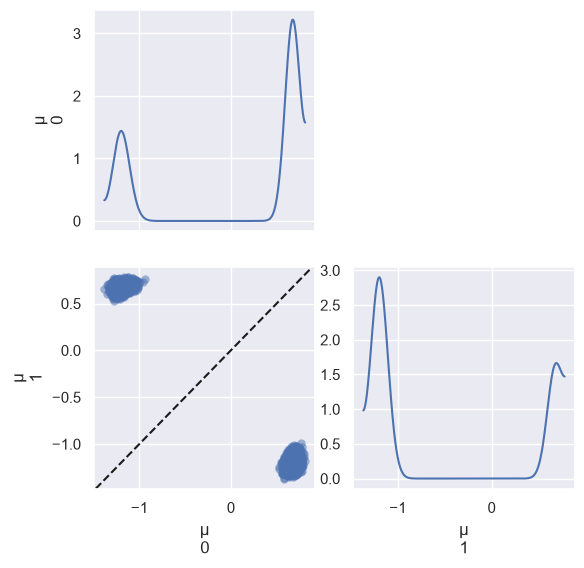

In [21]:
pmat = az.plot_pair(
    finite_trace,
    var_names="μ",
    figure_kwargs={"figsize": (6, 6), "subplot_kws": {"box_aspect": 1}},
)

ax = pmat.viz["plot"][1, 0].item()
ax.axline((0, 0), slope=1, c="k", ls="--")

ax.figure.tight_layout();

We see that the joint distribution is bimodal, and those modes appear to be reflections of each other around the line $\mu_1 = \mu_0$.  This symmetry strongly suggests we are experiencing [label switching](https://mc-stan.org/docs/2_20/stan-users-guide/label-switching-problematic-section.html), a phenomenon in many discrete latent parameter models that arises because their likelihood is invariant under permutations of the latent discrete parametrs (and the corresponding permutations of the component parameters).

To validate this conclusion, we plot the mean traces for the first two chains.

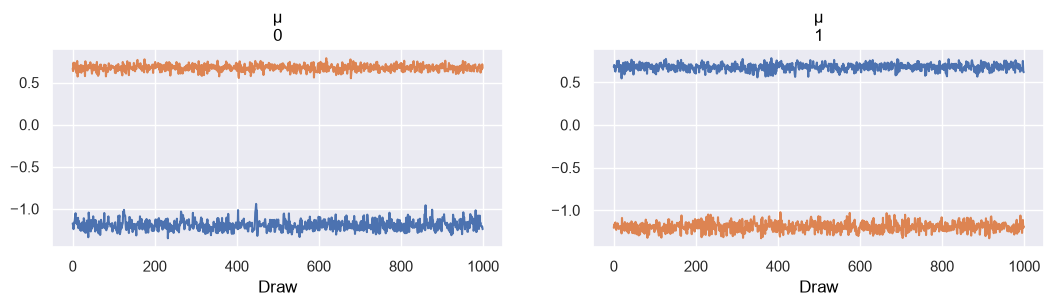

In [22]:
az.plot_trace(finite_trace, var_names="μ", coords={"chain": [0, 1]});

We see that indeed the actual values of the means are the same in both chains (different colored plots), but that what is labelled $\mu_0$ in the first chain is labelled $\mu_1$ in the second, and vice versa.

#### Ordering constraints

The standard method for breaking this permutation symmetry that makes the model [non-identifiable](https://en.wikipedia.org/wiki/Identifiability) is to introduce an ordering constraint on one of the component distribution parameters.  Here we build almost the same model, but apply PyMC's [`ordered`](https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.distributions.transforms.ordered.html) transformation to ensure $\mu_0 < \mu_1$.

In [23]:
with pm.Model(coords=COORDS) as finite_ord_model:
    w = pm.Dirichlet("w", np.ones(K))

    μ = pm.Normal(
        "μ",
        0,
        2.5,
        dims="component",
        transform=pm.distributions.transforms.ordered,
        initval=[-1, 1],
    )
    σ = pm.HalfNormal("σ", 2.5, dims="component")

    pm.NormalMixture("std_wait", w, μ, σ, observed=std_wait)

We now sample from this ordered-mean model and examine its $\hat{R}$ statistics.

In [24]:
finite_ord_trace = sample(finite_ord_model)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1400,0,0.79,7
,1400,0,0.61,7
,1400,0,0.74,3
,1400,0,0.64,3
,1400,0,0.76,7
,1400,0,0.74,7


We see $\hat{R}$ values quite close to one, indicating much better sampling. The pair and trace plots also confirm the lack of label switching for this model.

In [25]:
az.rhat(finite_ord_trace).max()

<xarray.DataTree 'posterior'>
Group: /
    Dimensions:  ()
    Data variables:
        w        float64 8B 1.001
        μ        float64 8B 1.001
        σ        float64 8B 1.002

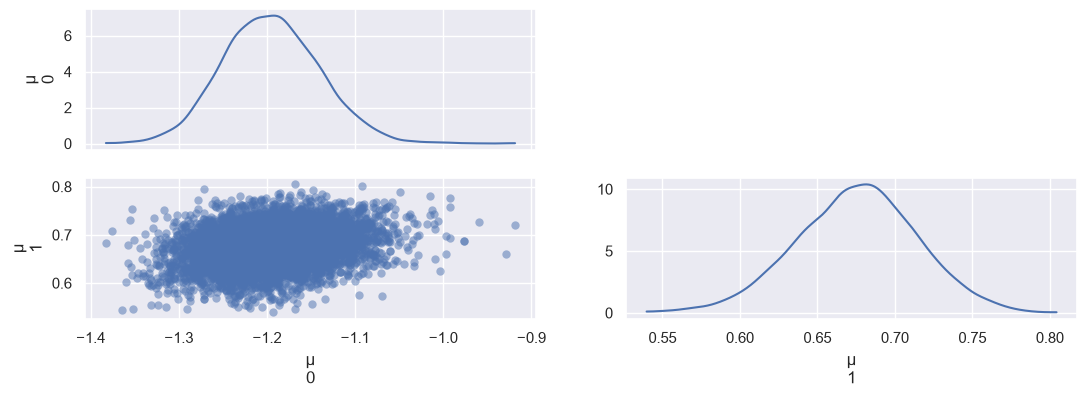

In [26]:
az.plot_pair(finite_ord_trace, var_names="μ");

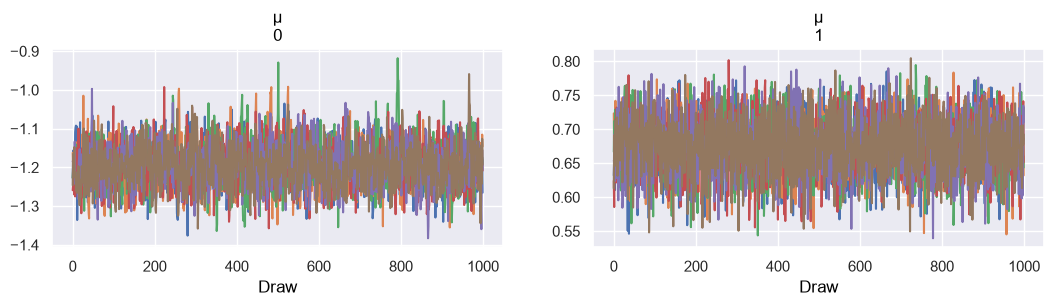

In [27]:
az.plot_trace(finite_ord_trace, var_names="μ");

Now that we are satisfied with our sampling, we visualize the posterior distribution of the mixture probability density.

In [28]:
def calculate_mix_logp(model, trace, grid=GRID):
    with model:
        try:
            mix_dist = pm.NormalMixture.dist(model["w"], model["μ"], model["σ"])
            pm.Deterministic("mix_logp", pm.logp(mix_dist, grid), dims="grid")
        except ValueError as e:
            # if "mix_logp" already exists, proceed straight to calculation
            if "already exists" in str(e):
                pass
            else:
                raise

        return pm.sample_posterior_predictive(
            trace, sample_vars="mix_logp", progressbar=False
        ).posterior_predictive["mix_logp"]

In [29]:
finite_ord_mix_logp = calculate_mix_logp(finite_ord_model, finite_ord_trace)

Sampling: []


In [30]:
CI_WIDTH = 0.95

ci_qs = [(1 - CI_WIDTH) / 2, 1 - (1 - CI_WIDTH) / 2]

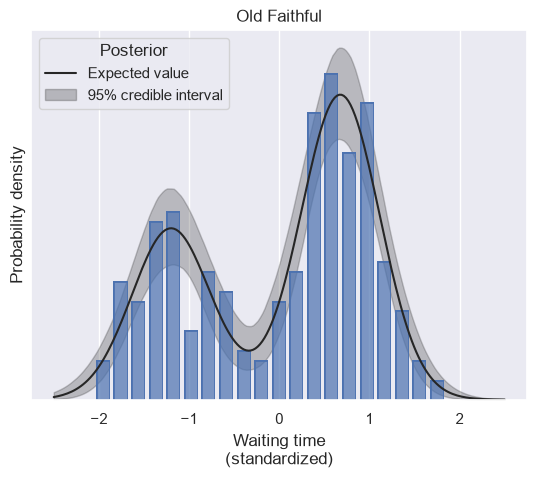

In [31]:
_, ax = plt.subplots()

ax.plot(
    GRID,
    finite_ord_mix_logp.pipe(np.exp).mean(dim=("chain", "draw")),
    c="k",
    label="Expected value",
)
ax.fill_between(
    GRID,
    *finite_ord_mix_logp.pipe(np.exp).quantile(ci_qs, dim=("chain", "draw")),
    color="k",
    alpha=0.25,
    label=f"{CI_WIDTH:.0%} credible interval",
)

ax.legend(title="Posterior")

hist.on(ax).show();

We see that the posterior expected value is a reasonable fit to the data.  Unlike with standard kernel density estimation (like we used for exploratory data analysis), the Bayesian approach naturally quantifies the uncertainty in this distribution.

#### Nonparametric Bayesian mixture models

 Outside of having to introduce an ordering constraint on the mean to identify the model, the above analysis was fairly straightforward.  It did, however, rely on the fact that we had a good idea of the number of mixture components a priori.  In the spirit of Bayesian statistics, it would be ideal to place a prior on the number of mixture components and then perform inference on the number of these components. This desire puts us firmly in the domain of Bayesian nonparametric statistics, which has two primary tools, [Gaussian processes](https://en.wikipedia.org/wiki/Gaussian_process) and [Dirichlet processes](https://en.wikipedia.org/wiki/Dirichlet_process).  Dirichlet processes are more applicable to our situation.

##### Dirichlet processes mixtures

The previous post gives a much deeper exposition of Diriclet processes in general (a fascinating topic, to be sure).  Since this post 
is focused on mixture models, we skip that exposition and focus on the [stick-breaking process](https://en.wikipedia.org/wiki/Dirichlet_process#The_stick-breaking_process) formulation most relevant to these models.

To facilitate Bayesian inference on the number of comoponents, a Dirichlet process mixture assumes that there are may be infinitely many, with weights $w_1, w_2, \ldots $.  Given a concentraction parameter $\alpha \geq 0$, the stick-breaking process constructs a distribution on these weights as follows.

1. Sample $\beta_1, \beta_2, \ldots \sim \text{Beta}(1, \alpha)$.
2. Let $w_k = \beta_k \cdot \prod_{\ell = 1}^{k - 1} (1 - \beta_{\ell})$.

To get a sense of how the concentration parameter, $\alpha$, controls the distribution of the weights, note that

$$\mathbb{E}(\beta_k) = \frac{1}{1 + \alpha},$$

so

$$\mathbb{E}(w_k) = \frac{1}{1 + \alpha} \cdot \left(\frac{\alpha}{1 + \alpha}\right)^{k - 1} = \frac{1}{\alpha} \cdot \left(\frac{\alpha}{1 + \alpha}\right)^k.$$

Below we visualize the expected values of the first ten component weights for various values of $\alpha$.

In [32]:
def exp_w(α, K):
    return 1 / α * (α / (1 + α)) ** (1 + np.arange(K))

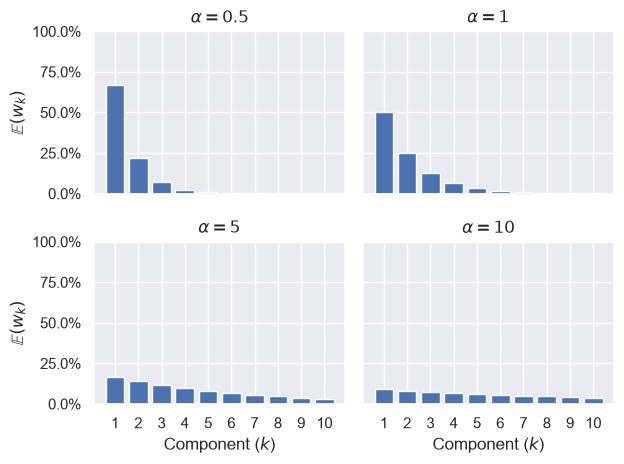

In [33]:
K_PLOT = 10
ALPHAS = [0.5, 1, 5, 10]

fig, axes = plt.subplots(len(ALPHAS) // 2, 2, sharex=True, sharey=True)

for α, ax in zip(ALPHAS, axes.flatten()):
    ax.bar(1 + np.arange(K_PLOT), exp_w(α, K_PLOT))

    ax.set_title(f"$\\alpha = {α}$")

for ax in axes[-1]:
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1, 1))
    ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))
    ax.set_xlabel("Component ($k$)")

for ax in axes[:, 0]:
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25, 0))
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1%}"))
    ax.set_ylabel(r"$\mathbb{E}(w_k)$")

fig.tight_layout();

We see that smaller values of $\alpha$ favor more weight in early components and a quickly decaying tail, whereas higher values favor more uniformly distributed and slowly decaying early components.

In practice, we cannot simulate infinitely many weights, so we turn to _truncated_ Dirichlet process mixtures.  In a truncated Dirichlet process mixture, we set the maximum possible number of components, $K_{\max}$, to be well above the likely true number of components in the data generating process.  The truncated stick breaking process is defined as follows.

1. Sample $\beta_1, \beta_2, \ldots, \beta_{K_{\max} - 1} \sim \text{Beta}(1, \alpha)$.
2. Let

$$\tilde{w}_k = \begin{cases}
    \beta_k \cdot \displaystyle\prod_{\ell = 1}^{k - 1} (1 - \beta_{\ell})
        & \text{if } k = 1, 2, \ldots, K_{\max} - 1 \\
    1 - \displaystyle\sum_{k = 1}^{K_{\max} - 1} \tilde{w}_k
        & \text{if } k = K_{\max}
\end{cases}.$$

When truncating, we use the final component's weight to ensure the sum-to-one constraint is satisfied.  For those readers interested in more details on truncated stick-breaking processes, Ishwaran and James's [_Gibbs Sampling Methods for Stick-Breaking Priors_](https://ishwaran.org/papers/stickBreaking.pdf) is an excellent reference.

The above expression for $\mathbb{E}(w_k)$ allows us to derive a heuristic for choosing $K_{\max}$.  Since

$$1 = \sum_{k = 1}^{\infty} w_k = \sum_{k = 1}^{K_{\max} - 1} \tilde{w}_k + \sum_{k = K_{\max}}^{\infty} w_k,$$

we have that

$$
\begin{align*}
    \mathbb{E}(\tilde{w}_{K_{\max}})
        & = 1 - \sum_{k = 1}^{K_{\max} - 1} \mathbb{E}(\tilde{w}_k) \\
        & = \sum_{k = K_{\max}}^{\infty} \mathbb{E}(w_k) \\
        & = \frac{1}{\alpha} \cdot \sum_{k = K_{\max}}^{\infty} \left(\frac{\alpha}{1 + \alpha}\right)^k \\
        & = \frac{1}{\alpha} \cdot \left(\frac{\alpha}{1 + \alpha}\right)^{K_{\max}} \cdot \sum_{k = 0}^{\infty} \left(\frac{\alpha}{1 + \alpha}\right)^k \\
        & = \left(\frac{\alpha}{1 + \alpha}\right)^{K_{\max} - 1}.
\end{align*}
$$

Therefore, if we want to ensure the expected weight truncated into the final component is less than $w^*$, we get

$$(K_{\max} - 1) \cdot (\log \alpha - \log(1 + \alpha))) < \log w^*,$$

which gives

$$K_{\max} > 1 + \frac{\log w^*}{\log \alpha - \log(1 + \alpha))}.$$

To choose $K_{\max}$ for our Old Faithful model, we must first place a prior on $\alpha$.  The original paper that introduced Dirichlet process mixutres, Antoniak's [_Mixtures of Dirichlet Processes with Applications to Bayesian Nonparametric Problems_](https://projecteuclid.org/journals/annals-of-statistics/volume-2/issue-6/Mixtures-of-Dirichlet-Processes-with-Applications-to-Bayesian-Nonparametric-Problems/10.1214/aos/1176342871.full), shows that the expected number of active components in a Dirichlet process mixture is

$$\mathbb{E}(K) \approx \mathbb{E}(\alpha) \cdot \log n,$$

where $n$ is the number of data points observed.  For the Old Faithful data, this means our prior on $\alpha$ should have expected value

In [34]:
exp_α = 2 / np.log(std_wait.size).item()

exp_α

0.35677321038940796

We use PreliZ's [maximum entropy](https://en.wikipedia.org/wiki/Maximum_entropy_probability_distribution) functionality to choose a lognormal prior that has the desired mean and 99% of its mass in the interval $[0, 5]$, which contains the hypothesized number of components.

/var/folders/bk/qh5dmxdx7618p2vpz30_mcdm0000gn/T/ipykernel_89044/1116493396.py:1: UserWarning: 
The requested mass is 0.99,
but the computed one is 0.999
  α_prior, ax = pz.maxent(


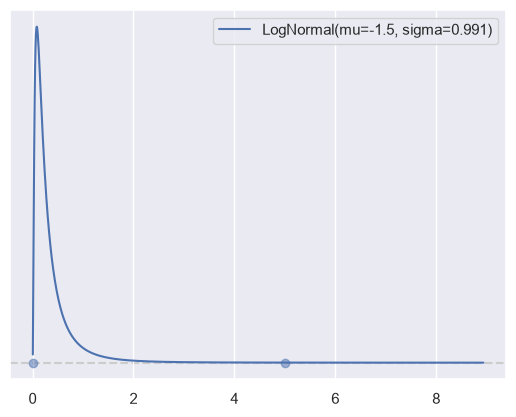

In [35]:
α_prior, ax = pz.maxent(
    pz.LogNormal(), lower=0, upper=5, mass=0.99, fixed_stat=("mean", exp_α)
)

ax.legend(loc="upper right");

Using this prior, we can calculate $K_{\max}$ using $\alpha = 5$ to be safe even if we have underestimated the number of required components.

In [36]:
def calculate_k_max(w_thresh, α):
    return 1 + (np.log(w_thresh) / (np.log(α) - np.log1p(α))).item()

In [37]:
ACTIVE_THRESH = 1e-3
K_MAX = ceil(calculate_k_max(1e-3, 5))

K_MAX

39

In [38]:
DPM_COORDS = {"component": np.arange(K_MAX), "grid": GRID}

We now specify this prior on $\alpha$.  We use PyMC's [`StickBreakingWeights`](https://www.pymc.io/projects/docs/en/stable/api/distributions/generated/pymc.StickBreakingWeights.html) distribution for the prior on $w$.

In [39]:
with pm.Model(coords=DPM_COORDS) as dpm_ord_model:
    α = α_prior.to_pymc("α")
    w = pm.StickBreakingWeights("w", α, K_MAX - 1, dims="component")

The rest of the model is analagous to the finite ordered model above.

In [40]:
with dpm_ord_model:
    μ = pm.Normal(
        "μ",
        0,
        2.5,
        dims="component",
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-3, 3, K_MAX),
    )
    σ = pm.HalfNormal("σ", 2.5, dims="component")

    pm.NormalMixture("std_waiting", w, μ, σ, observed=std_wait)

We now sample from this model.

In [41]:
DPM_SAMPLE_KWARGS = {"target_accept": 0.95, "tune": 1_000}

In [42]:
dpm_ord_trace = sample(dpm_ord_model, **DPM_SAMPLE_KWARGS)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.00,1023
,2000,10,0.00,15
,2000,0,0.00,1023
,2000,0,0.00,1023
,2000,285,0.01,1
,2000,0,0.00,1023


There are some divergences, which often indicate model geometry issues.  The the $\hat{R}$ statistics also exceed 1.01, confirming that we should investigate these samples closely.

In [43]:
az.rhat(dpm_ord_trace).max()

<xarray.DataTree 'posterior'>
Group: /
    Dimensions:  ()
    Data variables:
        α        float64 8B 4.621
        w        float64 8B 6.852
        μ        float64 8B 5.406
        σ        float64 8B 5.038

Interestingly, even in the unordered finite mixture model, the $\hat{R}$ for $\sigma$ was not too large, so it makes sense to start exploring there.

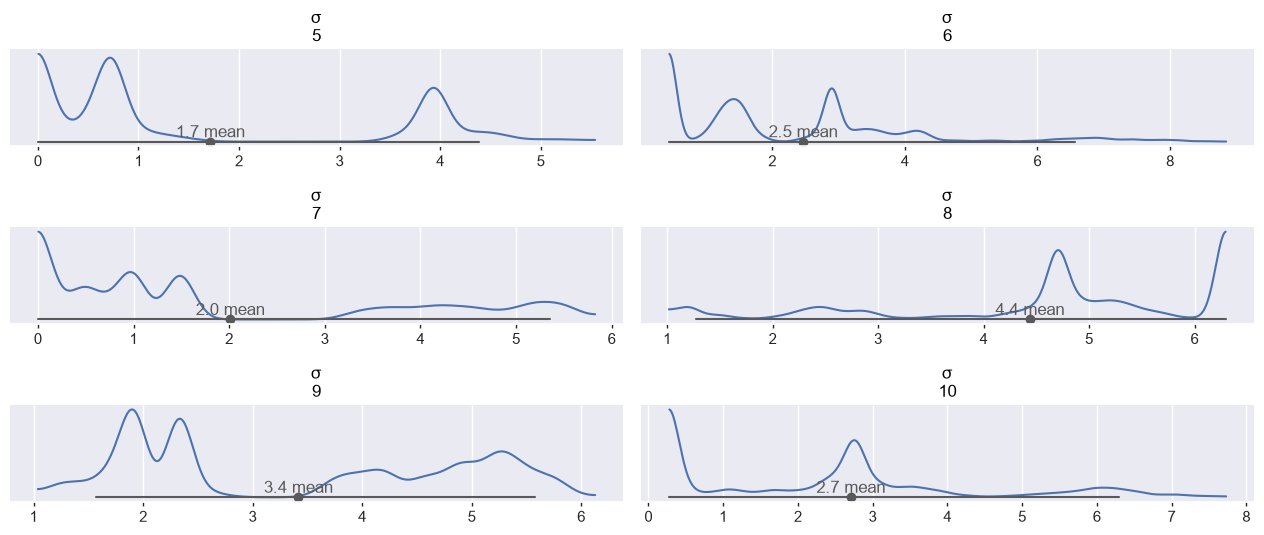

In [44]:
pmat = az.plot_dist(
    dpm_ord_trace,
    var_names="σ",
    coords={"component": range(5, 11)},
    col_wrap=2,
)

pmat.viz["plot"]["σ"][0].item().figure.tight_layout();

Here we show the posterior distributions for the scale parameter of six mixture components that we expect to be largely unused.  Below, we plot the scale parameters from the finite ordered model for comparison.

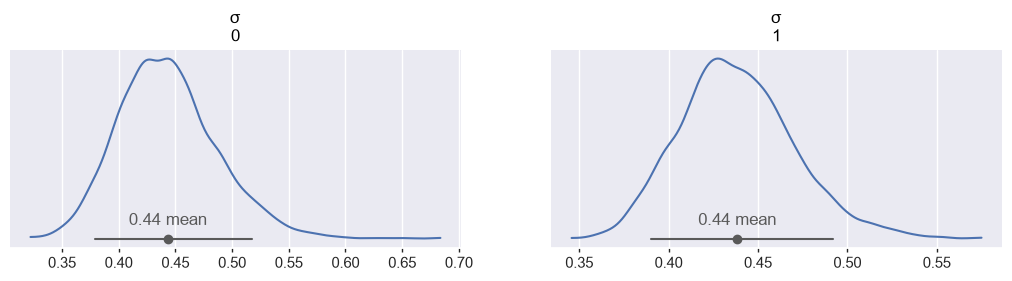

In [45]:
az.plot_dist(finite_ord_trace, var_names="σ");

Immediately we see that the Dirichlet process mixture posteriors are much more concentrated near zero in many cases.  This is a function of the prior geometry of the half-normal prior, as shown below.

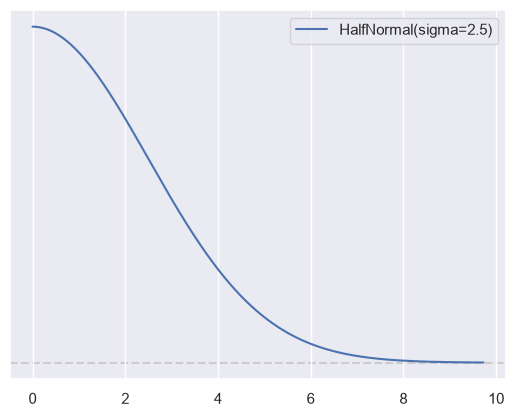

In [46]:
ax = pz.from_pymc(σ).plot_pdf()

ax.legend(loc="upper right");

We see here that the half-normal prior assigns the highest probability density to zero.  In the case of the finite mixture model, enough samples correspond to each component for the data to overwhelm the prior and move the posterior density well away from zero.  By design in the Dirichlet process mixture model, many components will have no corresponding samples, causing instablity around the hard zero-boundary.

To remedy this issue, we will place a lognormal prior on $\sigma_k$.

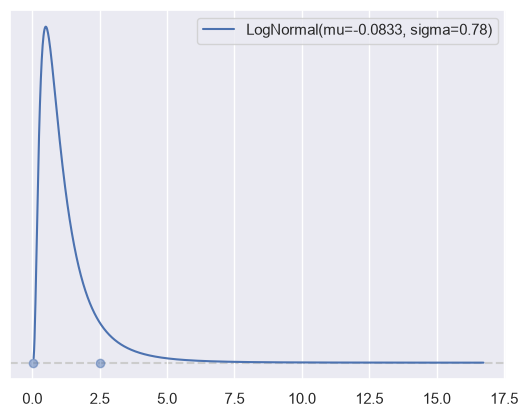

In [47]:
σ_prior, ax = pz.maxent(pz.LogNormal(), 0.01, 2.5, 0.9)

ax.legend(loc="upper right");

Note that this prior does not assign any density to zero. In fact, a log-transformed version of it will be unconstrained with a normal density, which can be sampled from very efficiency.

We now reimplement the ordered Dirichlet process mixture model using this prior and sample from it.

In [48]:
with pm.Model(coords=DPM_COORDS) as dpm_ord2_model:
    α = α_prior.to_pymc("α")
    w = pm.StickBreakingWeights("w", α, K_MAX - 1, dims="component")

    μ = pm.Normal(
        "μ",
        0,
        2.5,
        dims="component",
        transform=pm.distributions.transforms.ordered,
        initval=np.linspace(-3, 3, K_MAX),
    )
    σ = σ_prior.to_pymc("σ", dims="component")

    pm.NormalMixture("std_waiting", w, μ, σ, observed=std_wait)

In [49]:
dpm_ord2_trace = sample(dpm_ord2_model, **DPM_SAMPLE_KWARGS)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,1,0.07,63
,2000,27,0.04,127
,2000,0,0.03,127
,2000,0,0.04,127
,2000,0,0.07,63
,2000,11,0.05,127


There are some divergences, although fewer than with the previous model.  The the $\hat{R}$ statistics also exceed 1.01, though are lower than with the previous model as well.

In [50]:
az.rhat(dpm_ord2_trace).max()

<xarray.DataTree 'posterior'>
Group: /
    Dimensions:  ()
    Data variables:
        α        float64 8B 1.511
        w        float64 8B 1.534
        μ        float64 8B 1.224
        σ        float64 8B 1.044

Due to the elevated $\hat{R}$ values, we look again for sampling issues before turning to inference. Examining the pairplot for the two component means, we see that many samples are concentrated on the border line $\mu_0 = \mu_1$.  While the samples seem to want to cross this boundary, the ordering constraint on the means prohibits that behavior.

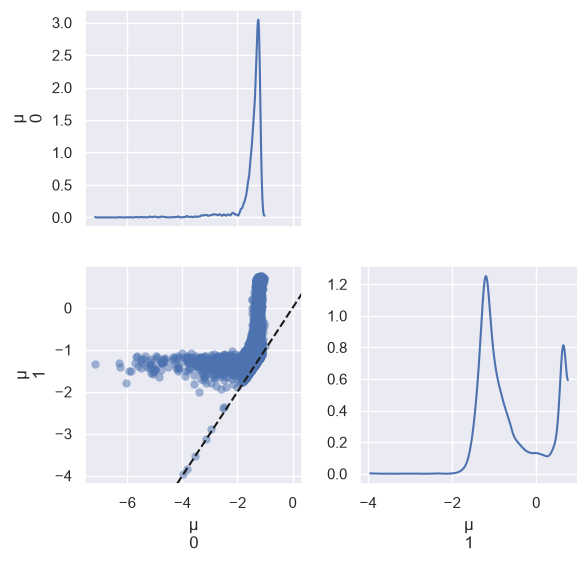

In [51]:
pmat = az.plot_pair(
    dpm_ord2_trace,
    var_names="μ",
    coords={"component": [0, 1]},
    figure_kwargs={"figsize": (6, 6), "subplot_kws": {"box_aspect": 1}},
)

ax = pmat.viz["plot"][1, 0].item()
ax.axline((0, 0), slope=1, c="k", ls="--")

ax.figure.tight_layout();

Notably, we do not see this behavior in the finite ordered model, so it is worth investigating further.

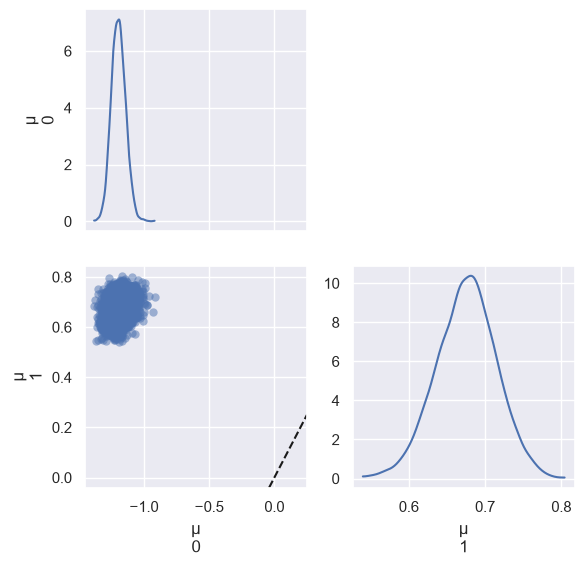

In [52]:
pmat = az.plot_pair(
    finite_ord_trace,
    var_names="μ",
    coords={"component": [0, 1]},
    figure_kwargs={"figsize": (6, 6), "subplot_kws": {"box_aspect": 1}},
)

ax = pmat.viz["plot"][1, 0].item()
ax.axline((0, 0), slope=1, c="k", ls="--")

ax.set_xlim(right=0.25)
ax.figure.tight_layout();

To investigate further, we plot examine pair plots of the first two component means and weights.

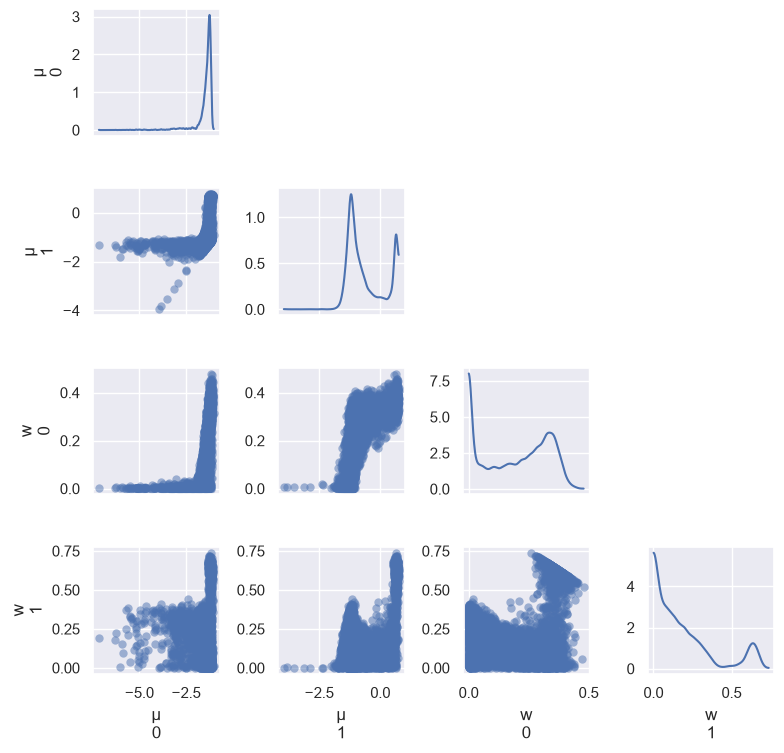

In [53]:
pmat = az.plot_pair(
    dpm_ord2_trace,
    var_names=["μ", "w"],
    coords={"component": [0, 1]},
    figure_kwargs={"figsize": (8, 8), "subplot_kws": {"box_aspect": 1}},
)

pmat.viz["plot"][0, 0].item().figure.tight_layout();

The plot of $w_0$ against $\mu_0$ is interesting, so we examine it more closely.

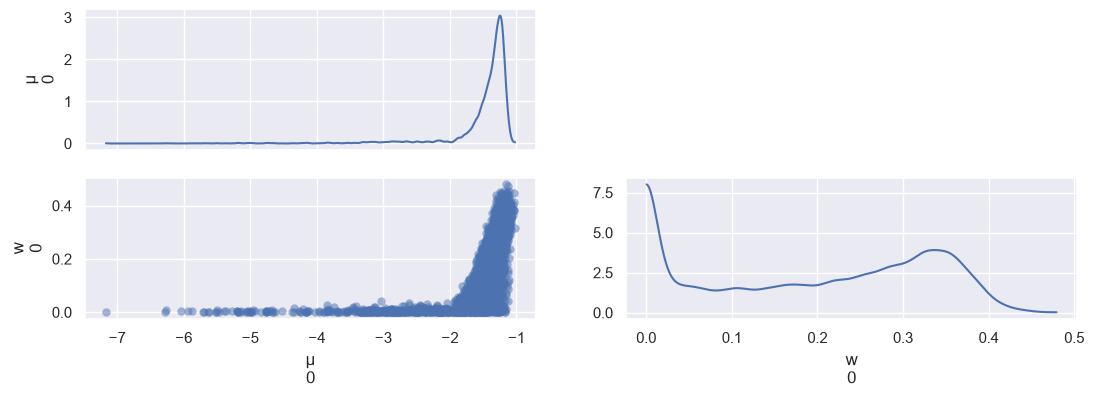

In [54]:
az.plot_pair(dpm_ord2_trace, var_names=["μ", "w"], coords={"component": [0]});

We see that many of the samples for the first component's weight are near zero and that when that weight is near zero, the mean can vary freely, as it does not contribute anything to the model. We confirm this behavior by looking at the plots for the a single trace.

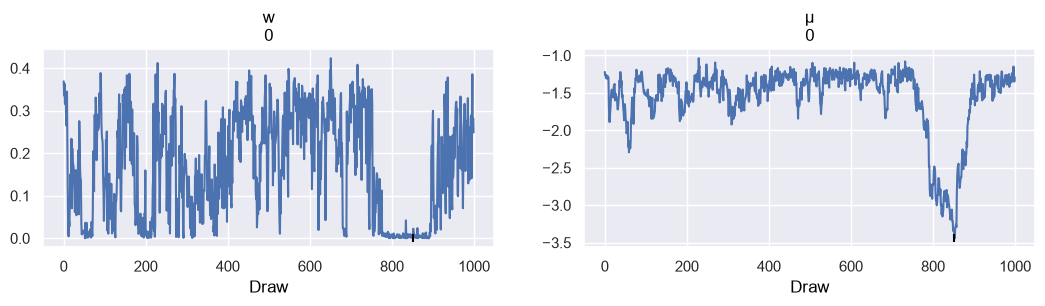

In [55]:
az.plot_trace(
    dpm_ord2_trace, var_names=["w", "μ"], coords={"component": [0], "chain": [0]}
);

What we see here is two prior constraints conflicting with one another.  The ordered transformation on the means ensure that $\mu_0$ must be the smallest mean, but a small expected value of $\alpha$ encourages most of the mass from the stick-breaking prior on $w$ to concentrate in the first component.

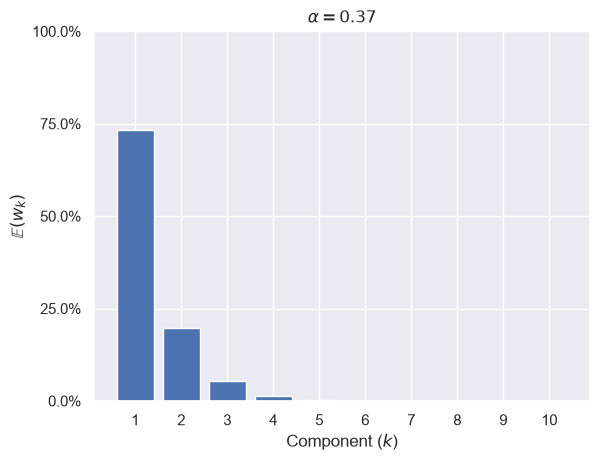

In [56]:
_, ax = plt.subplots()

ax.bar(1 + np.arange(K_PLOT), exp_w(α_prior.mean(), K_PLOT))

ax.set_title(f"$\\alpha = {α_prior.mean():.2f}$")

ax.xaxis.set_major_locator(ticker.MultipleLocator(1, 1))
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.0f}"))
ax.set_xlabel("Component ($k$)")

ax.set_ylim(0, 1)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25, 0))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:.1%}"))
ax.set_ylabel(r"$\mathbb{E}(w_k)$");

However, it is clear that the second mixture component of the (standardized) waiting times, with the larger mean, should have the highest mixture weight.

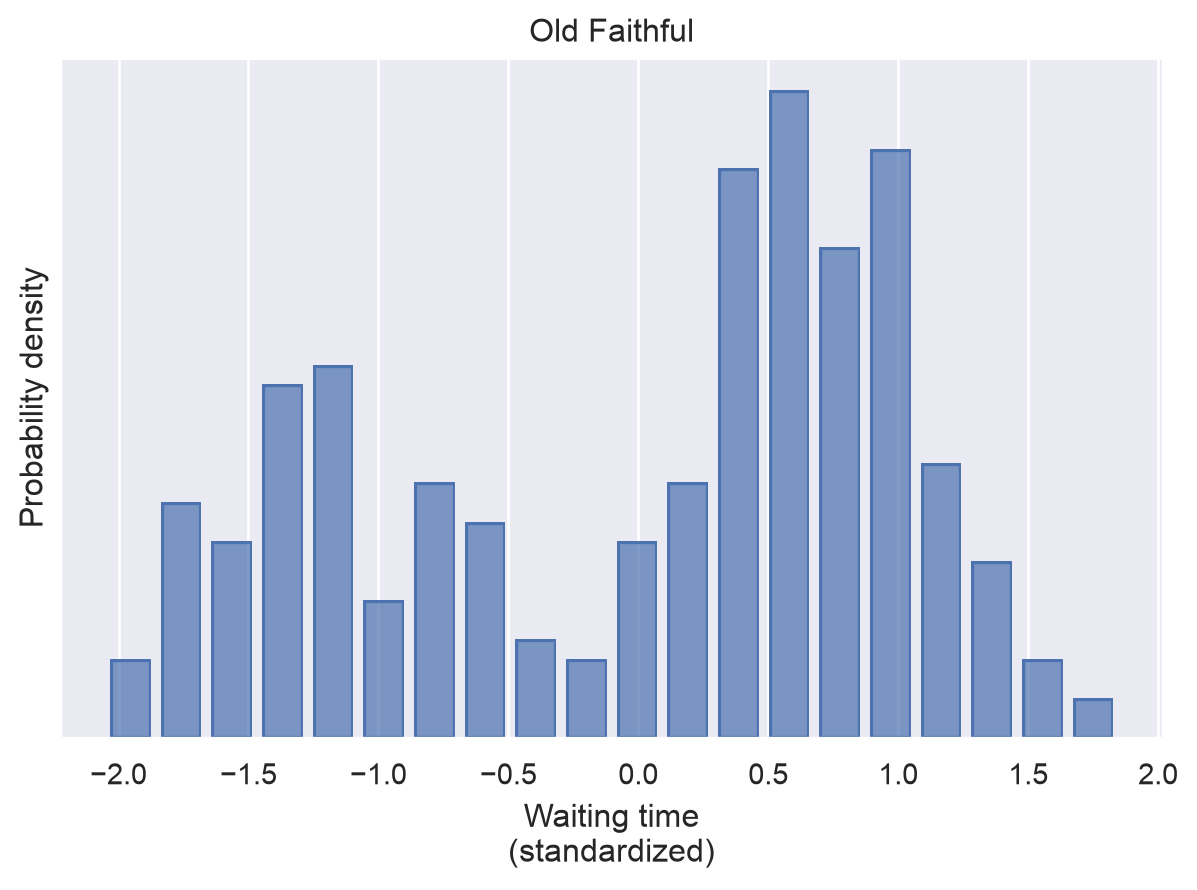

In [57]:
hist

Therefore we must relax one of these two constraints.  Since we chose the prior on $\alpha$, and therefore $w$, to be informative based on the hypothesized number of mixture components, we remove the ordering constraint from the means.

In [58]:
with pm.Model(coords=DPM_COORDS) as dpm_model:
    α = α_prior.to_pymc("α")
    w = pm.StickBreakingWeights("w", α, K_MAX - 1, dims="component")

    μ = pm.Normal("μ", 0, 2.5, dims="component")
    σ = σ_prior.to_pymc("σ", dims="component")

    pm.NormalMixture("std_waiting", w, μ, σ, observed=std_wait)

We sample from this model.

In [59]:
dpm_trace = sample(dpm_model, **DPM_SAMPLE_KWARGS)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.08,383
,2000,0,0.05,191
,2000,0,0.08,63
,2000,0,0.07,63
,2000,0,0.08,63
,2000,0,0.06,127


There are no divergences, is an improvement.  Examining the $\hat{R}$ statistics, we see that they are high, which is expected due to label switching, as we have removed the ordering constraint from the means.

In [60]:
az.rhat(dpm_trace).max()

<xarray.DataTree 'posterior'>
Group: /
    Dimensions:  ()
    Data variables:
        μ        float64 8B 1.617
        α        float64 8B 1.494
        w        float64 8B 1.597
        σ        float64 8B 1.023

The following trace plot confirms that we are experiencing label switching as expected.

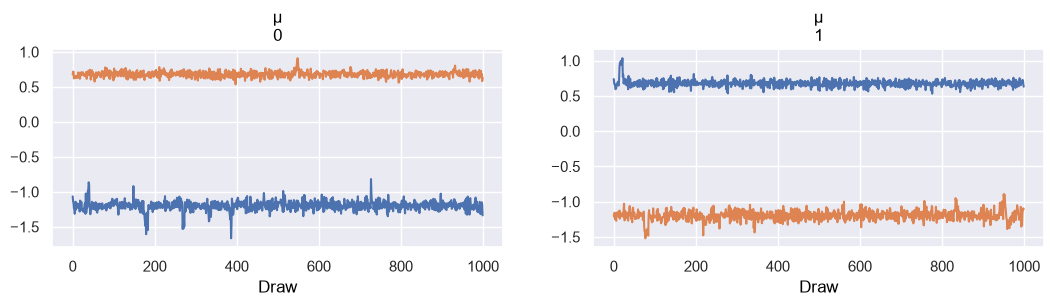

In [61]:
az.plot_trace(dpm_trace, var_names="μ", coords={"component": [0, 1], "chain": [0, 1]});

The quantity we really care about, however, is the mixture density, so we calculate that and examine its $\hat{R}$.

In [62]:
dpm_mix_logp = calculate_mix_logp(dpm_model, dpm_trace)

Sampling: []


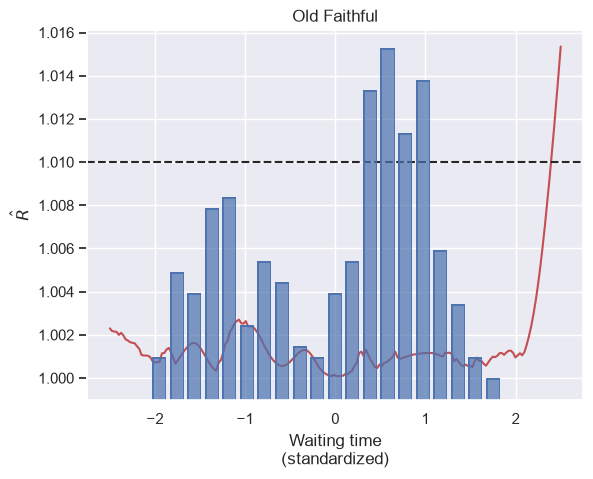

In [63]:
_, ax = plt.subplots()

ax.plot(GRID, az.rhat(dpm_mix_logp), c="C3")
ax.axhline(1.01, c="k", ls="--")

ax.set_xlabel(OF_XLABEL)

ax.set_ylim(0.999)
ax.set_ylabel(r"$\hat{R}$")

hist_ax = ax.twinx()
hist.label(y=None).on(hist_ax).show();

This plot shows how the mixture density's $\hat{R}$ varies over the grid on which we have evaluated it.  We see that $\hat{R} < 1.01$ in regions that are covered by the data and only increase when we venture intro extrapotation, so we are satisfied with these results.

Now that we are satisfied with the quality of these samples, we visualize the posterior mixture likelihood.

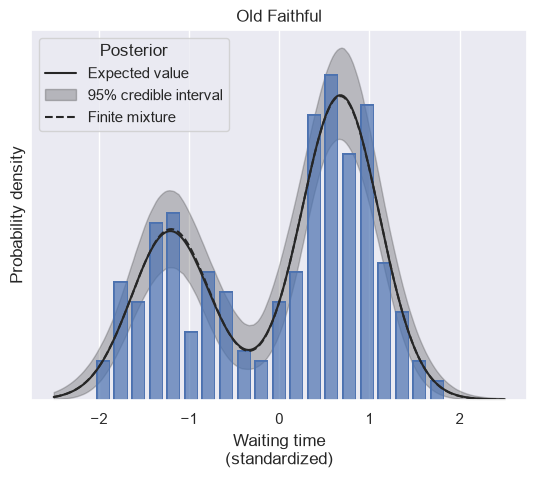

In [64]:
_, ax = plt.subplots()


ax.plot(
    GRID,
    dpm_mix_logp.pipe(np.exp).mean(dim=("chain", "draw")),
    c="k",
    label="Expected value",
)
ax.fill_between(
    GRID,
    *dpm_mix_logp.pipe(np.exp).quantile(ci_qs, dim=("chain", "draw")),
    color="k",
    alpha=0.25,
    label=f"{CI_WIDTH:.0%} credible interval",
)
ax.plot(
    GRID,
    finite_ord_mix_logp.pipe(np.exp).mean(dim=("chain", "draw")),
    c="k",
    ls="--",
    label="Finite mixture",
)

ax.legend(title="Posterior")

hist.on(ax).show();

We see excellent agreement with the finite ordered mixture model's posterior mixture density, without having had to specify the number of mixture components.

We also see that the most likely number of posterior active components is two, but that there are a decent number of samples with a few more.

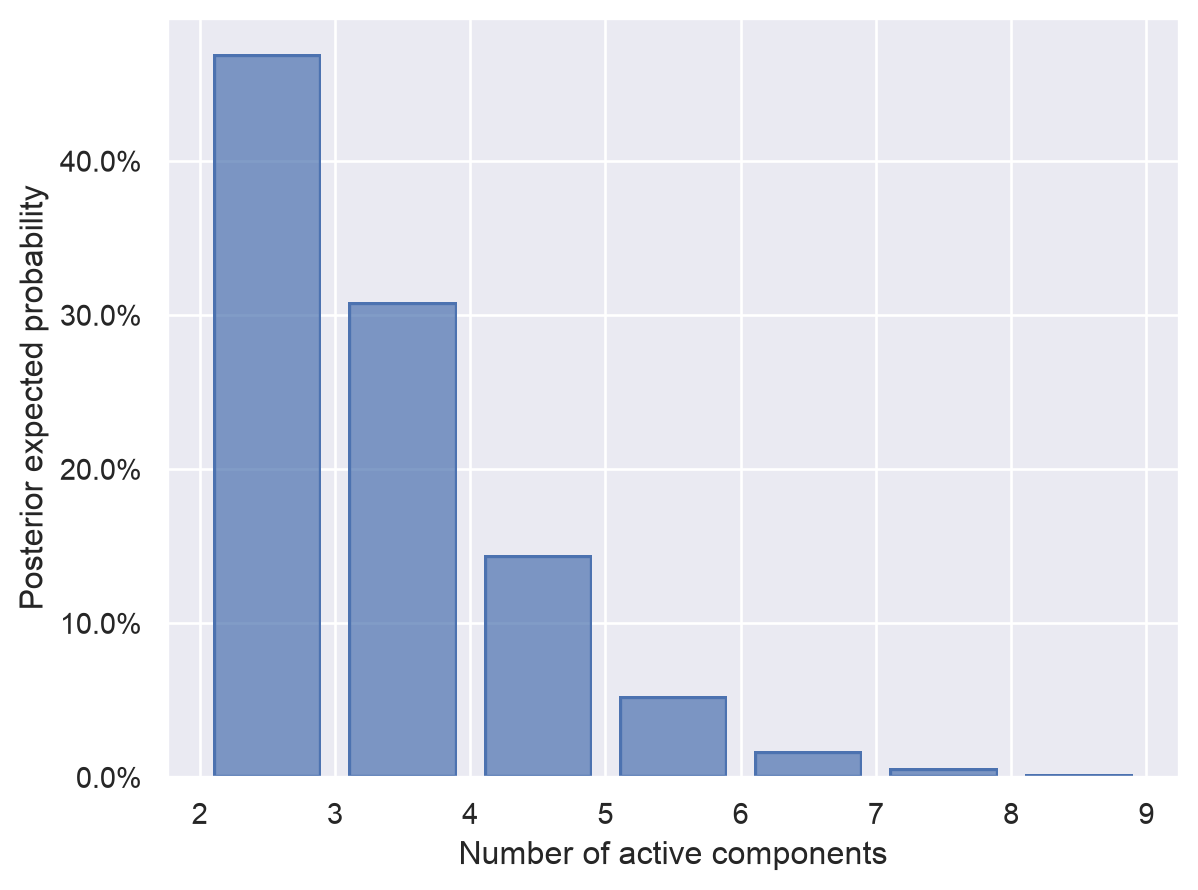

In [65]:
(
    so.Plot(
        (dpm_trace.posterior["w"] > ACTIVE_THRESH)
        .sum(dim="component")
        .stack(flat=[...])
    )
    .add(so.Bar(), so.Hist(binwidth=1, stat="density"))
    .scale(y=so.Continuous().label(like="{x:.1%}"))
    .label(x="Number of active components", y="Posterior expected probability")
)

It is a well-known property of Dirichlet process mixtures that they are not [consistent estimators](https://en.wikipedia.org/wiki/Consistency_(statistics)) of the number of true components and can be prone to overfitting.  See Miller and Harrison's [_Inconsistency of Pitman-Yor Process Mixtures for the Number of Components_](https://jmlr.org/papers/v15/miller14a.html) for a detail discussion of this phenomenon.

In this post we have explored five different Bayesian mixture models on a toy dataset, starting with a simple finite mixture model and working our way up to a nonparametric (theoretically) infinite Dirichlet process mixture model.  Along the way we saw what is necessary and achievable in terms of identification, sampling performance, and estimator consistency.

I hope you have enjoyed reading this post as much as I have enjoyed writing it!

This post is available as a Jupyter notebook [here](https://nbviewer.org/gist/AustinRochford/a9cdeb30c6638023feda98c2a26b3581).

**AI usage transparency:** I have used various AI models to refine, simplify, and validate some of the mathematics and modeling in this post.  I have also used AI to check spelling and grammar for correctness and quality.  _However, AI has not directly created, changed, or edited any of the content in this post.  It started with my writing and all AI suggestions were reviewed and incorporated manually by me._

In [66]:
%load_ext watermark
%watermark -n -u -v -iv

Last updated: Thu, 20 Aug 2026

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.16.1

arviz     : 1.3.0
matplotlib: 3.11.1
numpy     : 2.3.5
nutpie    : 0.16.11
polars    : 1.43.2
preliz    : 0.27.1
pymc      : 6.3.1
scipy     : 1.18.0
seaborn   : 0.13.2

